In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("travel.sqlite")
cur = conn.cursor()

In [9]:
query = "SELECT name FROM sqlite_master WHERE type='table'"
pd.read_sql(query, conn)


,name
0,aircrafts_data
1,airports_data
2,boarding_passes
3,bookings
4,flights
5,seats
6,ticket_flights
7,tickets


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [11]:
# 1) The average price, per fare_condition

In [12]:
query1 = """
SELECT fare_conditions,
       ROUND(AVG(amount), 2) AS avg_price
FROM ticket_flights
GROUP BY fare_conditions
ORDER BY fare_conditions;
"""

df_avg_pricess = pd.read_sql(query1, conn)

fig = px.bar( df_avg_pricess, x="avg_price",  y="fare_conditions", orientation="h", title="Average prices of Classes")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# 2) To know from which Airport to most delays were

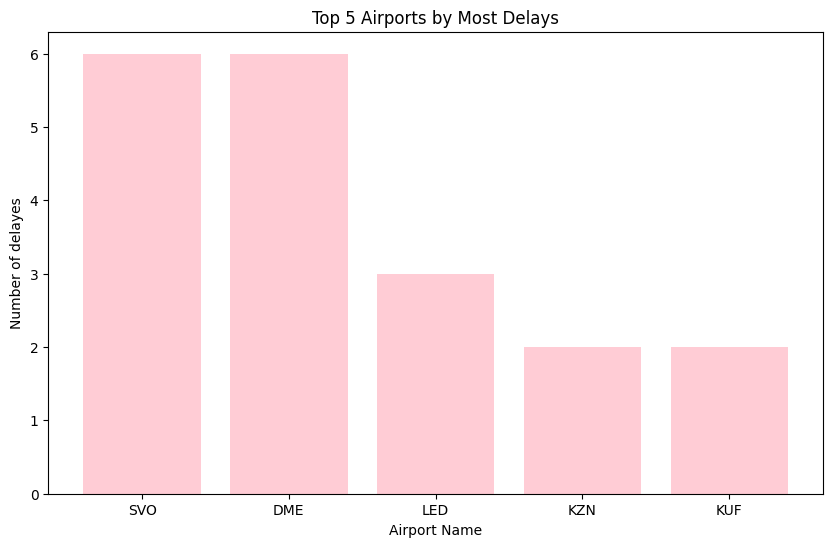

In [ ]:
query2 = """
SELECT departure_airport,
       SUM(CASE WHEN status = 'Delayed' THEN 1 ELSE 0 END) AS n_delays
FROM flights
GROUP BY departure_airport
ORDER BY n_delays DESC LIMIT 5;
"""

df_top_delayes = pd.read_sql(query2, conn)


plt.figure(figsize=(10, 6))
plt.bar(df_top_delayes["departure_airport"], df_top_delayes["n_delays"], color="pink", alpha=0.8)
plt.title("Top 5 Airports by Most Delays")
plt.xlabel("Airport Name")
plt.ylabel("Number of delayes")
plt.show()

In [ ]:
# This means, that from the all the airports, the 2 in Moscow, Russia called
# "Sheremetyevo International Airport" and "Domodedovo International Airport" had the most delays recorded.

In [ ]:
# 3) The most popular destinations (which Airports had the most arrivals)

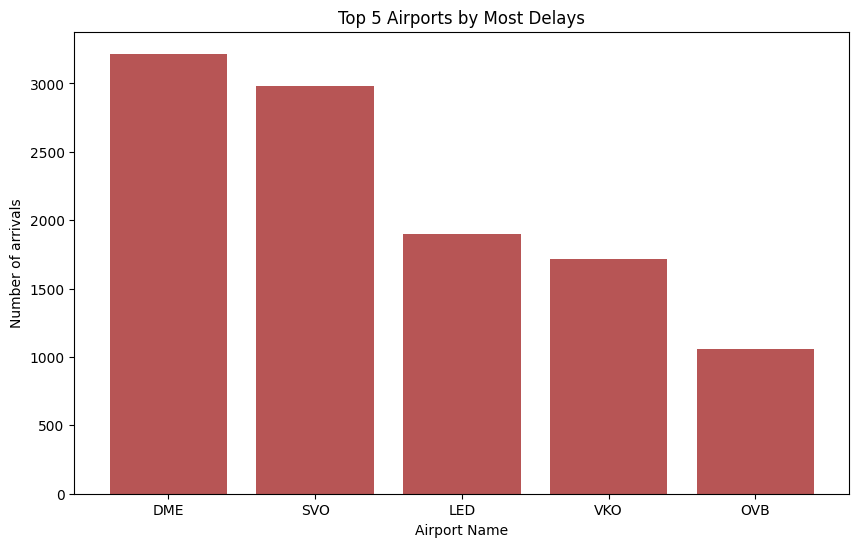

In [ ]:
query3 = """
SELECT arrival_airport,
       COUNT(flight_id) AS n_flights
FROM flights
GROUP BY arrival_airport
ORDER BY n_flights DESC LIMIT 5;
"""

df_top_airports = pd.read_sql(query3, conn)


plt.figure(figsize=(10, 6))
plt.bar(df_top_airports["arrival_airport"], df_top_airports["n_flights"], color="brown", alpha=0.8)
plt.title("Top 5 Airports by Most Delays")
plt.xlabel("Airport Name")
plt.ylabel("Number of arrivals")
plt.show()

In [ ]:
# This means, that although the delays were rcorded from the above mentioned 2 airports,
# they serve also most of the flights, which may be the cause of the delays.

In [ ]:
# 4) Which aircraft model is having the most flights

/tmp/ipython-input-2263302850.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




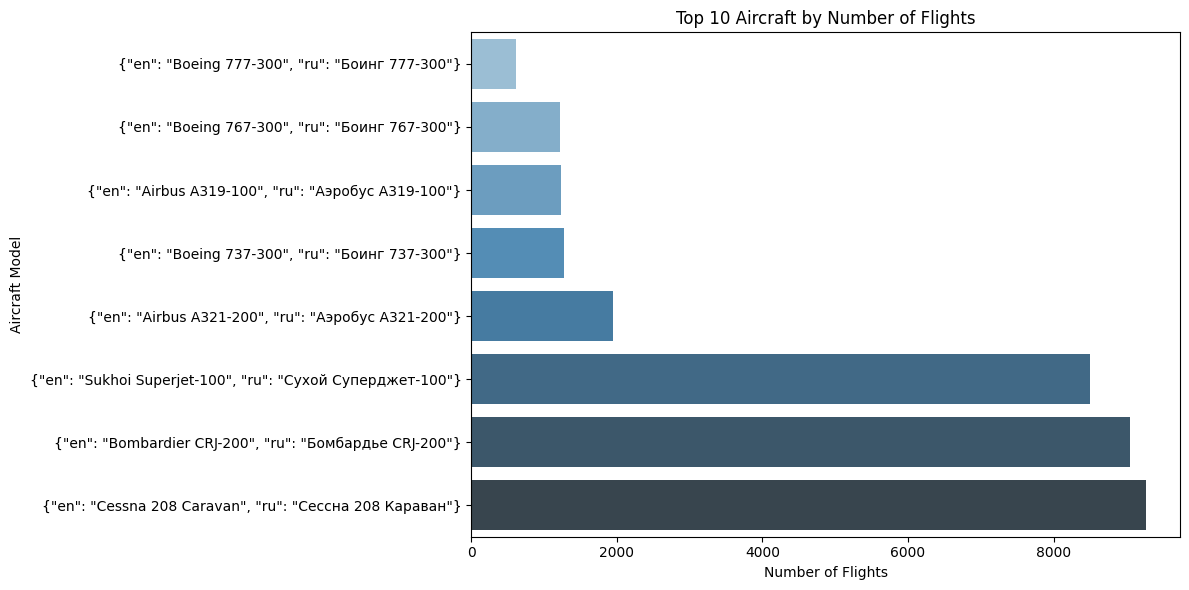

In [ ]:
query4 = """
SELECT flights.aircraft_code,
       aircrafts_data.model AS aircraft_model,
       COUNT(flights.flight_id) AS n_flights
FROM flights
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code
GROUP BY flights.aircraft_code, aircrafts_data.model
ORDER BY n_flights
LIMIT 10;
"""

df_top_flights = pd.read_sql(query4, conn)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_top_flights,
    x="n_flights",
    y="aircraft_model",
    orient="h",
    palette="Blues_d"
)

plt.xlabel("Number of Flights")
plt.ylabel("Aircraft Model")
plt.title("Top 10 Aircraft by Number of Flights")
plt.tight_layout()
plt.show()

In [ ]:
# The results show that the CN1 and CR2 aircrafts are carring the most flights, so they are popular.

In [ ]:
# 5) The aircrafts which generates the most revenue

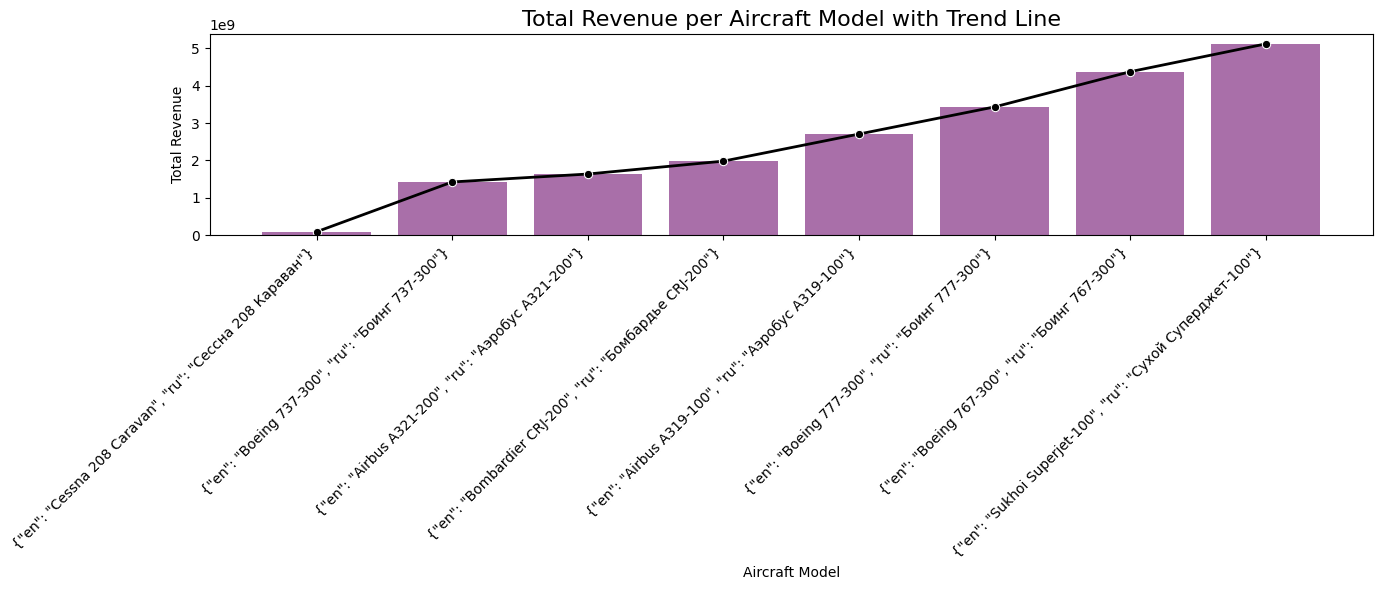

In [ ]:
query5 = """
SELECT flights.aircraft_code,
       aircrafts_data.model AS aircraft_model,
       SUM(ticket_flights.amount) AS total_revenue
FROM flights
JOIN ticket_flights
    ON flights.flight_id = ticket_flights.flight_id
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code
GROUP BY flights.aircraft_code, aircrafts_data.model
ORDER BY total_revenue;
"""

df_revenue = pd.read_sql(query5, conn)

df_revenue = df_revenue.sort_values("total_revenue")

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_revenue,
    x="aircraft_model",
    y="total_revenue",
    color="purple",
    alpha=0.6
)

sns.lineplot(
    data=df_revenue,
    x="aircraft_model",
    y="total_revenue",
    color="black",
    linewidth=2,
    marker="o"
)

plt.title("Total Revenue per Aircraft Model with Trend Line", fontsize=16)
plt.xlabel("Aircraft Model")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.tight_layout()
plt.show()

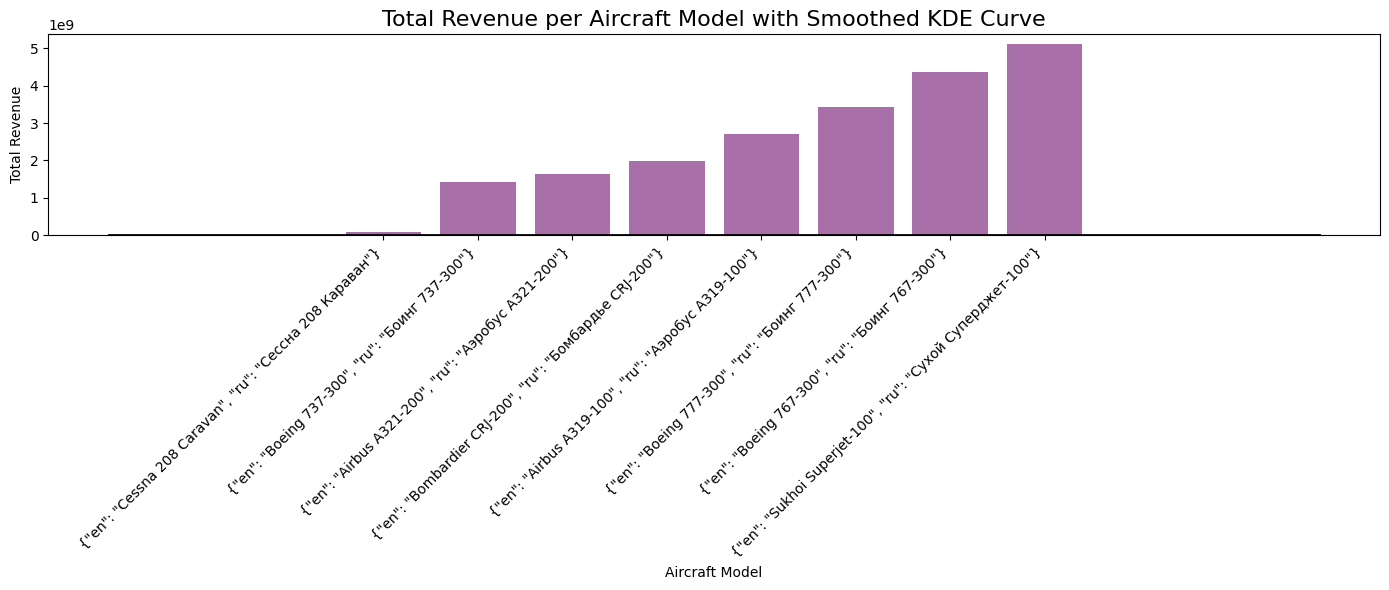

In [ ]:
query5 = """
SELECT flights.aircraft_code,
       aircrafts_data.model AS aircraft_model,
       SUM(ticket_flights.amount) AS total_revenue
FROM flights
JOIN ticket_flights
    ON flights.flight_id = ticket_flights.flight_id
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code
GROUP BY flights.aircraft_code, aircrafts_data.model
ORDER BY total_revenue;
"""

df_revenue = pd.read_sql(query5, conn)

df_revenue = df_revenue.sort_values("total_revenue", ascending=True)

df_revenue["x_pos"] = range(len(df_revenue))

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_revenue,
    x="aircraft_model",
    y="total_revenue",
    color="purple",
    alpha=0.6
)

sns.kdeplot(
    data=df_revenue,
    x="x_pos",
    weights="total_revenue",
    bw_adjust=0.6,
    color="black",
    linewidth=2,
)

plt.xticks(
    ticks=df_revenue["x_pos"],
    labels=df_revenue["aircraft_model"],
    rotation=45,
    ha="right"
)

plt.title("Total Revenue per Aircraft Model with Smoothed KDE Curve", fontsize=16)
plt.xlabel("Aircraft Model")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [ ]:
# As we can see the SU9 is the highest revunew generaing aircraft for our Customers.

In [ ]:
# 6) I would like to know which proportion of the flights were business, comfort, economy classes for each aircraft.

In [ ]:
query6 = """
SELECT flights.aircraft_code,
       aircrafts_data.model AS aircraft_model,
       SUM(CASE WHEN ticket_flights.fare_conditions = 'Business' THEN 1 ELSE 0 END) * 1.0 / COUNT(ticket_flights.ticket_no) AS business_rate
FROM flights
JOIN ticket_flights
    ON flights.flight_id = ticket_flights.flight_id
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code
GROUP BY flights.aircraft_code, aircrafts_data.model
ORDER BY business_rate DESC;
"""
df_business = pd.read_sql(query6, conn)
df_business = df_business.sort_values("business_rate", ascending=False)

fig = px.area(
    df_business,
    x="aircraft_model",
    y="business_rate",
    title="Business Class Proportion per Aircraft"
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis=dict(range=[0, 1])
)

fig.show()

In [ ]:
# The picture is very interesting. My hypothesis was that SU9 is the leading in revenuew generating,
# beacuse most of the tickets are from business class. However, there are 3 aircrafts who have higher rate of business class passengers,
# in addition, these aircrafts are quit behide in revenuew generating compared to the top 3.

In [ ]:
# Thank you!!!

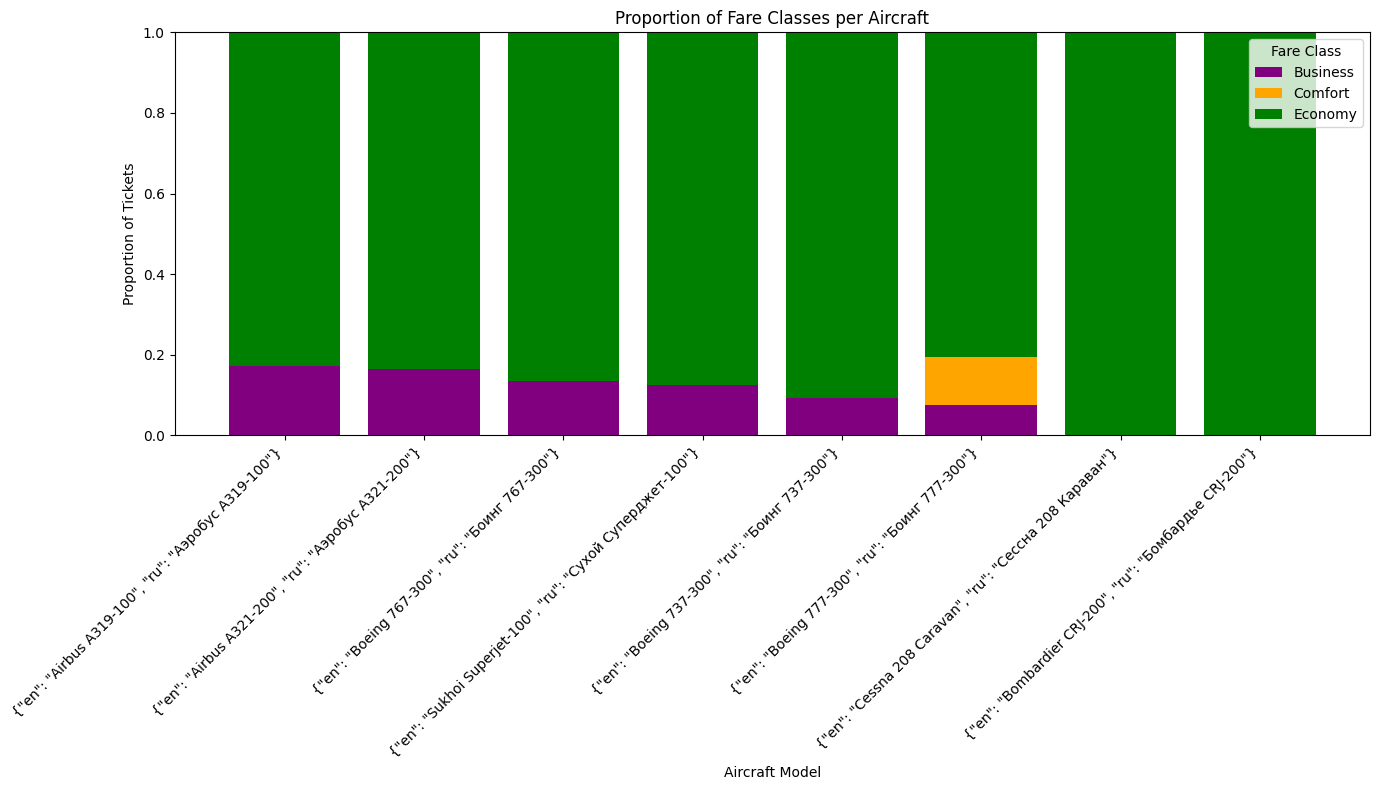

In [ ]:
query7 = """
SELECT
    flights.aircraft_code,
    aircrafts_data.model AS aircraft_model,

    SUM(CASE WHEN ticket_flights.fare_conditions = 'Business' THEN 1 ELSE 0 END) * 1.0 / COUNT(ticket_flights.ticket_no) AS business_rate,

    SUM(CASE WHEN ticket_flights.fare_conditions = 'Comfort' THEN 1 ELSE 0 END) * 1.0 / COUNT(ticket_flights.ticket_no) AS comfort_rate,

    SUM(CASE WHEN ticket_flights.fare_conditions = 'Economy' THEN 1 ELSE 0 END) * 1.0 / COUNT(ticket_flights.ticket_no) AS economy_rate

FROM flights
JOIN ticket_flights
    ON flights.flight_id = ticket_flights.flight_id
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code

GROUP BY flights.aircraft_code, aircrafts_data.model
ORDER BY business_rate DESC;
"""

df_class = pd.read_sql(query7, conn)

df_class = df_class.sort_values("business_rate", ascending=False)

plt.figure(figsize=(14, 8))

bottom_comfort = df_class["business_rate"]
bottom_economy = bottom_comfort + df_class["comfort_rate"]

plt.bar(df_class["aircraft_model"], df_class["business_rate"], color="purple", label="Business")
plt.bar(df_class["aircraft_model"], df_class["comfort_rate"], bottom=bottom_comfort, color="orange", label="Comfort")
plt.bar(df_class["aircraft_model"], df_class["economy_rate"], bottom=bottom_economy, color="green", label="Economy")

plt.ylabel("Proportion of Tickets")
plt.xlabel("Aircraft Model")
plt.title("Proportion of Fare Classes per Aircraft")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Fare Class")
plt.tight_layout()
plt.show()

In [ ]:
# Two of the aircrafts serve only economy class, and only one has all three classes.

In [ ]:
Squery7 = """
ELECT
    aircrafts_data.model AS aircraft_model,
    AVG(ticket_flights.amount) AS avg_revenue
FROM flights
JOIN ticket_flights
    ON flights.flight_id = ticket_flights.flight_id
JOIN aircrafts_data
    ON flights.aircraft_code = aircrafts_data.aircraft_code
GROUP BY aircraft_model
ORDER BY avg_revenue DESC;
"""
df = pd.read_sql(query, conn)

plt.figure(figsize=(12, 6))
plt.bar(df["aircraft_model"], df["avg_revenue"], color="skyblue")

plt.title("Average Ticket Revenue per Aircraft Model", fontsize=16)
plt.xlabel("Aircraft Model")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'avg_revenue'

<Figure size 1200x600 with 0 Axes>